# IoMT Ransomware Detection — Pipeline Demo

This notebook walks through every stage of the detection pipeline **live**, showing the actual code that runs at each step and what it produces.

The dataset used throughout is the **Simulated ICU** dataset — 80 virtual medical devices (ventilators, infusion pumps, monitors) each producing 500 timesteps of sensor and network readings. Ransomware begins at timestep 200 on attack devices.

---

## Pipeline at a Glance

```
┌─────────────────────────────────────────────────────────┐
│  Stage 1 — Raw Data                                     │
│  CSV of device telemetry (cpu, memory, entropy, ...)    │
└──────────────────────┬──────────────────────────────────┘
                       │
┌──────────────────────▼──────────────────────────────────┐
│  Stage 2 — Preprocessing                                │
│  Clean → Scale → Group-aware Train/Val/Test Split       │
└──────────────────────┬──────────────────────────────────┘
                       │
┌──────────────────────▼──────────────────────────────────┐
│  Stage 3 — Autoencoder  (trained on benign only)        │
│  Input (19) → Latent (32) + Reconstruction Error (1)    │
└──────────────────────┬──────────────────────────────────┘
                       │ 33-dim vector per timestep
┌──────────────────────▼──────────────────────────────────┐
│  Stage 4 — Sequence Construction                        │
│  Sliding window of 20 consecutive timesteps per device  │
└──────────────────────┬──────────────────────────────────┘
                       │
┌──────────────────────▼──────────────────────────────────┐
│  Stage 5 — Mamba Classifier                             │
│  Sequence (20 × 33) → Binary prediction (benign/attack) │
└──────────────────────┬──────────────────────────────────┘
                       │
              Benign / Ransomware
```

In [1]:
import os, sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, accuracy_score
)
from torch.utils.data import DataLoader

# Add the project root to Python's module search path so we can import from src/
sys.path.insert(0, os.path.abspath('.'))

# Import project modules
from src.config import Config                                   # all hyperparameters and file paths
from src.models.autoencoder import Autoencoder                  # Stage 3 model
from src.models.mamba_classifier import MambaClassifier         # Stage 6 model
from src.models.lstm_classifier import LSTMClassifier           # LSTM baseline
from src.datasets.sequence_dataset import ArraySequenceDataset  # Stage 5 windowing
from src.evaluate.metrics import find_optimal_threshold, compute_metrics  # evaluation helpers

# Initialise config (loads all hyperparameters and paths from src/config.py)
cfg    = Config()
device = torch.device('cpu')     # run on CPU; change to 'cuda' if a GPU is available
np.random.seed(cfg.random_seed)  # fix random seed so results are reproducible

print('Setup complete.')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')


Setup complete.
PyTorch version : 2.11.0+cpu
Device          : cpu


---
## Stage 1 — Raw Data

The Simulated ICU dataset is a synthetic but realistic representation of an IoMT environment. It contains readings from **80 virtual devices** across 4 device types:

- **Ventilator** — breathing support machines
- **Infusion pump** — drug delivery devices
- **Patient monitor** — vital signs tracking
- **ECG monitor** — heart rhythm recording

Each device produces **500 timesteps** of readings. On attack devices, ransomware begins at **timestep 200**, causing measurable changes in CPU usage, disk write rate, entropy, and auth failure counts.

The data has **23 columns**: 1 timestamp, 1 device ID, 1 device type, **19 numerical features**, and 1 label (0 = benign, 1 = ransomware).

In [2]:
# Load the raw CSV from disk into a pandas DataFrame
raw_df = pd.read_csv('data/raw/sim_raw/icu_simulation.csv')

# Print a high-level summary of the dataset
print(f'Shape            : {raw_df.shape}  ({raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns)')
print(f'Devices          : {raw_df["device_id"].nunique()} unique')
print(f'Device types     : {sorted(raw_df["device_type"].unique())}')
print(f'Timesteps/device : {raw_df.groupby("device_id").size().unique()[0]}')

# Show how many samples belong to each class
print(f'Label distribution:')
print(f'  Benign (0)  : {(raw_df["label"]==0).sum():,}')
print(f'  Attack (1)  : {(raw_df["label"]==1).sum():,}')
print()

# Show a sample of the key columns so we can see what the raw data looks like
print('Sample rows:')
raw_df[['device_id','device_type','cpu_usage','entropy','disk_write_rate',
        'auth_failure_count','network_bytes_out','label']].head(4)


Shape            : (40000, 23)  (40,000 rows x 23 columns)
Devices          : 80 unique
Device types     : ['infusion_pump', 'iomt_gateway', 'patient_monitor', 'ventilator']
Timesteps/device : 500
Label distribution:
  Benign (0)  : 28,000
  Attack (1)  : 12,000

Sample rows:


,device_id,device_type,cpu_usage,entropy,disk_write_rate,auth_failure_count,network_bytes_out,label
0,ventilator_normal_0,ventilator,21.219,3.2014,6.876,0,30.490,0
1,ventilator_normal_0,ventilator,20.873,3.3817,4.949,0,31.286,0
2,ventilator_normal_0,ventilator,17.408,3.7009,6.581,0,38.963,0
3,ventilator_normal_0,ventilator,16.618,3.9545,4.227,0,23.459,0


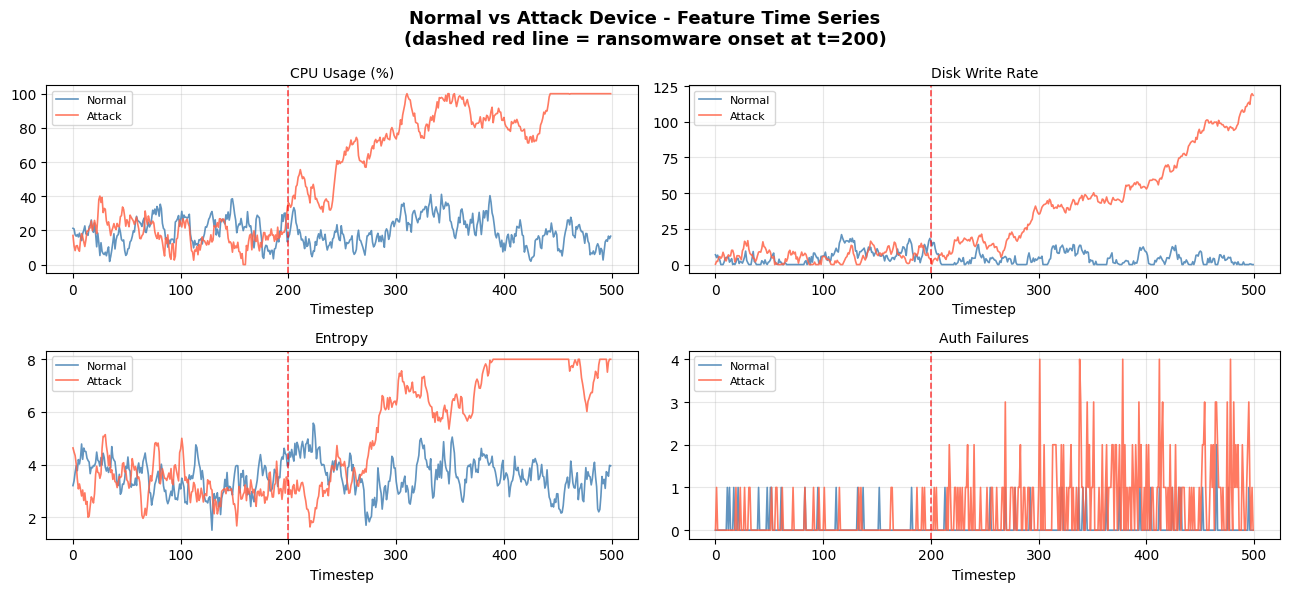

Notice how entropy and disk_write_rate spike sharply after timestep 200 on the attack device.


In [3]:
# Pick one normal device and one attack device of the same type to compare.
# Both are ventilators so any difference is due to the ransomware, not the device type.
normal_dev = raw_df[raw_df['device_id'] == 'ventilator_normal_0'].sort_values('timestamp')
attack_dev = raw_df[raw_df['device_id'] == 'ventilator_attack_0'].sort_values('timestamp')

# Choose features that visually show the ransomware effect
features_to_plot = ['cpu_usage', 'disk_write_rate', 'entropy', 'auth_failure_count']
titles           = ['CPU Usage (%)', 'Disk Write Rate', 'Entropy', 'Auth Failures']

fig, axes = plt.subplots(2, 2, figsize=(13, 6))
fig.suptitle('Normal vs Attack Device - Feature Time Series\n(dashed red line = ransomware onset at t=200)',
             fontsize=13, fontweight='bold')

for ax, feat, title in zip(axes.flat, features_to_plot, titles):
    # Plot both devices on the same axes so we can directly compare
    ax.plot(normal_dev['timestamp'], normal_dev[feat], label='Normal',
            color='steelblue', linewidth=1.2, alpha=0.85)
    ax.plot(attack_dev['timestamp'], attack_dev[feat], label='Attack',
            color='tomato',    linewidth=1.2, alpha=0.85)
    # Draw a vertical line at timestep 200 where ransomware begins
    ax.axvline(200, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Timestep')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Notice how entropy and disk_write_rate spike sharply after timestep 200 on the attack device.')


---
## Stage 2 — Preprocessing

Raw data cannot be fed directly into a neural network. The preprocessing stage does four things:

1. **Drop non-feature columns** — `timestamp`, `device_id`, `device_type`, and `label` are removed from the feature matrix. The label is kept separately as the target.

2. **Handle missing/invalid values** — Replace `inf`, `-inf`, and `NaN` with zero.

3. **Feature scaling** — Apply `StandardScaler` (fitted on training data only) so every feature has mean≈0 and std≈1. This prevents large-valued features from dominating the network.

4. **Group-aware train/val/test split** — Use `GroupShuffleSplit` with `group=device_id` so that all timesteps from a given device land entirely in one split. Without this, the model could learn device-specific patterns rather than attack patterns, and test scores would be misleadingly high.

The split follows the SRS requirement **DA-023**: **70% train / 15% validation / 15% test**.

### Key preprocessing code

```python
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# Split 1: trainval (85%) vs test (15%), grouped by device_id
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
trainval_idx, test_idx = next(gss1.split(X_df, y, groups=device_ids))

# Split 2: train (≈70% of total) vs val (≈15% of total)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)
train_rel, val_rel = next(gss2.split(X_trainval, y_trainval, groups=groups_trainval))

# Scale — fit ONLY on training data, then transform val and test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)
X_val   = scaler.transform(X_val_df)    # never fit on val/test
X_test  = scaler.transform(X_test_df)
```

> **Why group-aware splitting matters:** If `device_id = ventilator_attack_3` appears in both train and test, the model might memorise that specific device's baseline rather than learning what attack traffic looks like in general. GroupShuffleSplit guarantees each device is in exactly one split.

In [4]:
# Load the pre-computed splits from disk.
# These were produced by running: python -m src.preprocess.preprocess_sim
# Each file is a numpy array saved with np.save()

sp = cfg.sim_splits_path   # path to the sim splits directory (from config.py)

# Feature matrices: each row is one timestep, each column is one scaled feature
X_train = np.load(os.path.join(sp, 'X_train.npy'))
X_val   = np.load(os.path.join(sp, 'X_val.npy'))
X_test  = np.load(os.path.join(sp, 'X_test.npy'))

# Label vectors: 0 = benign, 1 = ransomware
y_train = np.load(os.path.join(sp, 'y_train.npy'))
y_val   = np.load(os.path.join(sp, 'y_val.npy'))
y_test  = np.load(os.path.join(sp, 'y_test.npy'))

# Group IDs: the device_id each row belongs to.
# Used by the sequence builder to keep windows within a single device's timeline.
g_train = np.load(os.path.join(sp, 'group_ids_train.npy'), allow_pickle=True)
g_val   = np.load(os.path.join(sp, 'group_ids_val.npy'),   allow_pickle=True)
g_test  = np.load(os.path.join(sp, 'group_ids_test.npy'),  allow_pickle=True)

# Print a summary table showing how the data is distributed across splits
total = len(X_train) + len(X_val) + len(X_test)
print(f'Feature dimensions : {X_train.shape[1]} features per timestep')
print()
print(f'{"Split":<10} {"Rows":>8}  {"% of total":>10}  {"Benign":>8}  {"Attack":>8}  {"Devices":>8}')
print('-' * 60)
for name, X, y, g in [("Train", X_train, y_train, g_train),
                       ("Val",   X_val,   y_val,   g_val),
                       ("Test",  X_test,  y_test,  g_test)]:
    pct = 100 * len(X) / total
    print(f'{name:<10} {len(X):>8,}  {pct:>9.1f}%  '
          f'{(y==0).sum():>8,}  {(y==1).sum():>8,}  {len(np.unique(g)):>8}')


Feature dimensions : 19 features per timestep

Split          Rows  % of total    Benign    Attack   Devices
------------------------------------------------------------
Train        27,500       68.8%    18,200     9,300        55
Val           6,500       16.2%     5,300     1,200        13
Test          6,000       15.0%     4,500     1,500        12


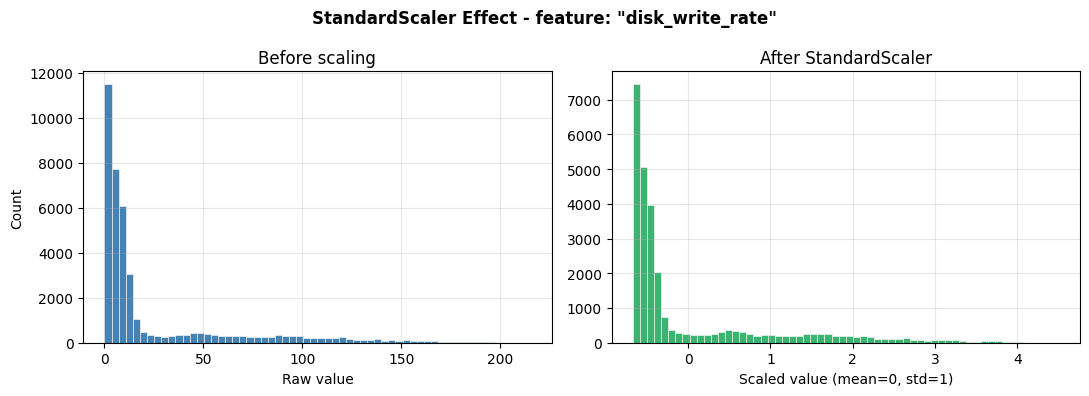

Before - mean: 24.98   std: 39.04
After  - mean: -0.0000  std: 1.0000


In [5]:
# Demonstrate the effect of StandardScaler on one feature.
# Neural networks train poorly when features have very different value ranges,
# so we scale every feature to have mean=0 and std=1 before training.

# Reconstruct the original (unscaled) feature values from the raw CSV
drop_cols = ['label','timestamp','device_id','device_type']
X_raw_df  = raw_df.drop(columns=drop_cols)   # drop non-feature columns to match X_train columns
feat_idx  = 2                                 # index of 'disk_write_rate' in the feature array
feat_name = X_raw_df.columns[feat_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(f'StandardScaler Effect - feature: "{feat_name}"', fontsize=12, fontweight='bold')

raw_vals    = X_raw_df.iloc[:, feat_idx].values   # original values before scaling
scaled_vals = X_train[:, feat_idx]                # values after fit_transform on training data

ax1.hist(raw_vals,    bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax1.set_title('Before scaling')
ax1.set_xlabel('Raw value')
ax1.set_ylabel('Count')
ax1.grid(True, alpha=0.3)

ax2.hist(scaled_vals, bins=60, color='mediumseagreen', edgecolor='white', linewidth=0.4)
ax2.set_title('After StandardScaler')
ax2.set_xlabel('Scaled value (mean=0, std=1)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Before - mean: {raw_vals.mean():.2f}   std: {raw_vals.std():.2f}')
print(f'After  - mean: {scaled_vals.mean():.4f}  std: {scaled_vals.std():.4f}')


---
## Stage 3 — Autoencoder (Anomaly Scoring)

The first stage of the detection pipeline is an **autoencoder** — a neural network trained to compress data and then reconstruct it.

### Why train on benign data only?

The autoencoder is trained exclusively on **normal (label=0) traffic**. It learns to compress and reconstruct healthy device behaviour accurately. When ransomware traffic is passed through the same network, the autoencoder has never seen anything like it — so it reconstructs it poorly, producing a high **reconstruction error**.

This means the reconstruction error acts as an **anomaly score**: low for benign traffic, high for attack traffic.

### Architecture

```
Input (19)  →  Hidden (128)  →  Hidden (64)  →  Latent (32)    [Encoder]
Latent (32) →  Hidden (64)   →  Hidden (128) →  Output (19)    [Decoder]
```

The output of the encoder — a 32-dimensional **latent vector** — is a compressed summary of the traffic sample. We append the reconstruction error to get a **33-dimensional representation** per timestep, which is what the sequence classifier consumes.

### Training

Loss function: **Mean Squared Error** between input and reconstruction.  
Training stops early when validation reconstruction loss stops improving (patience = 5 epochs).

In [6]:
# Print the Autoencoder class source code.
# This is the exact class used to build and train the model - no wrappers or abstractions.
# The encoder compresses the input to a 32-dim latent vector.
# The decoder tries to reconstruct the original input from that latent vector.
import inspect
from src.models.autoencoder import Autoencoder
print(inspect.getsource(Autoencoder))


class Autoencoder(nn.Module):
    def __init__(self, input_dim: int, hidden_dim1: int = 128, hidden_dim2: int = 64, latent_dim: int = 32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return z, x_hat

    def encode(self, x):
        return self.encoder(x)



In [7]:
# Instantiate the Autoencoder with the same architecture used during training.
# All dimension values come from cfg (src/config.py) so they match the saved weights exactly.
ae = Autoencoder(
    input_dim  = X_train.shape[1],    # 19: number of input features after preprocessing
    hidden_dim1= cfg.ae_hidden_dim1,  # 128: first hidden layer size
    hidden_dim2= cfg.ae_hidden_dim2,  # 64: second hidden layer size
    latent_dim = cfg.latent_dim,      # 32: bottleneck dimension (compressed representation)
).to(device)

# Load the saved weights from the trained model checkpoint file
ae.load_state_dict(torch.load(cfg.sim_autoencoder_model_path, map_location=device))
# eval() switches off dropout and freezes batch normalisation stats for inference
ae.eval()

# Count the total number of learnable parameters
total_params = sum(p.numel() for p in ae.parameters())
print(f'Autoencoder loaded  :  {cfg.sim_autoencoder_model_path}')
print(f'Total parameters    :  {total_params:,}')
print(f'Input dimension     :  {X_train.shape[1]}')
print(f'Latent dimension    :  {cfg.latent_dim}')
print()
print(ae)   # PyTorch prints a structured summary of every layer and its dimensions


Autoencoder loaded  :  models/autoencoder_sim.pt
Total parameters    :  25,779
Input dimension     :  19
Latent dimension    :  32

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=19, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=19, bias=True)
  )
)


Input shape          : (1, 19)
Latent (z) shape     : (1, 32)   <- compressed representation
Reconstruction shape : (1, 19) <- decoded back to original space
Reconstruction error : 0.000092  (MSE between input and reconstruction)
True label           : 0  (0 = benign)



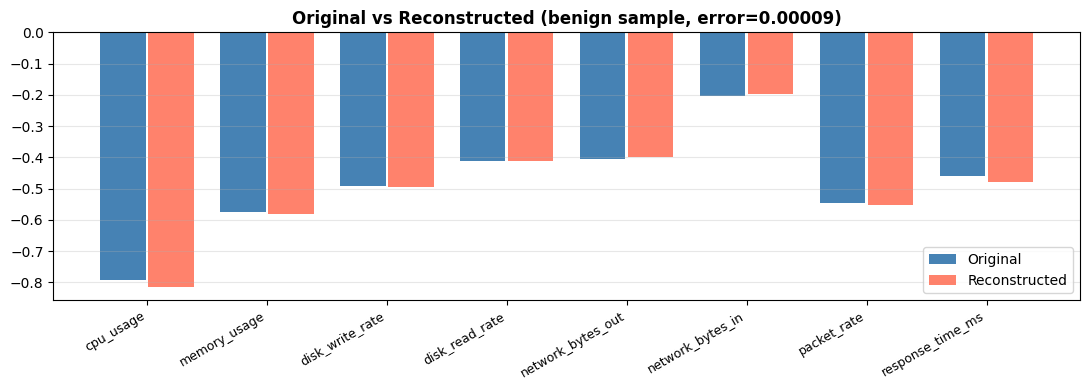

In [8]:
# Run a single test sample through the autoencoder to observe all intermediate values.
sample_idx = 0
# Convert the numpy row to a PyTorch tensor; unsqueeze adds a batch dimension (size 1)
x_raw = torch.tensor(X_test[sample_idx:sample_idx+1], dtype=torch.float32)

# torch.no_grad() disables gradient computation - we are doing inference, not training
with torch.no_grad():
    # ae.forward() returns both the latent vector and the reconstruction
    z, x_hat = ae(x_raw)   # z shape: (1, 32),  x_hat shape: (1, 19)

# Reconstruction error = mean squared difference between input and reconstruction.
# Low error means the AE understood this sample well (expected for benign).
# High error means the AE struggled to reconstruct it (expected for attacks).
recon_error = torch.mean((x_raw - x_hat) ** 2).item()

print('Input shape          :', tuple(x_raw.shape))
print('Latent (z) shape     :', tuple(z.shape),   '  <- compressed representation')
print('Reconstruction shape :', tuple(x_hat.shape), '<- decoded back to original space')
print(f'Reconstruction error : {recon_error:.6f}  (MSE between input and reconstruction)')
print(f'True label           : {int(y_test[sample_idx])}  (0 = benign)')
print()

# Plot the first 8 features side by side: original vs what the AE reconstructed.
# If the bars match closely, the AE understood the sample well.
n_show = 8
inp  = x_raw[0, :n_show].numpy()
rec  = x_hat[0, :n_show].numpy()
feat_names = list(raw_df.drop(columns=['label','timestamp','device_id','device_type']).columns[:n_show])

fig, ax = plt.subplots(figsize=(11, 4))
x_pos   = np.arange(n_show)
ax.bar(x_pos - 0.2, inp, 0.38, label='Original',       color='steelblue')
ax.bar(x_pos + 0.2, rec, 0.38, label='Reconstructed',  color='tomato', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(feat_names, rotation=30, ha='right', fontsize=9)
ax.set_title(f'Original vs Reconstructed (benign sample, error={recon_error:.5f})', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


Benign reconstruction error - mean: 0.00029  std: 0.00067
Attack reconstruction error - mean: 1.66653  std: 1.39458
Separation ratio: 5680.2x higher for attacks


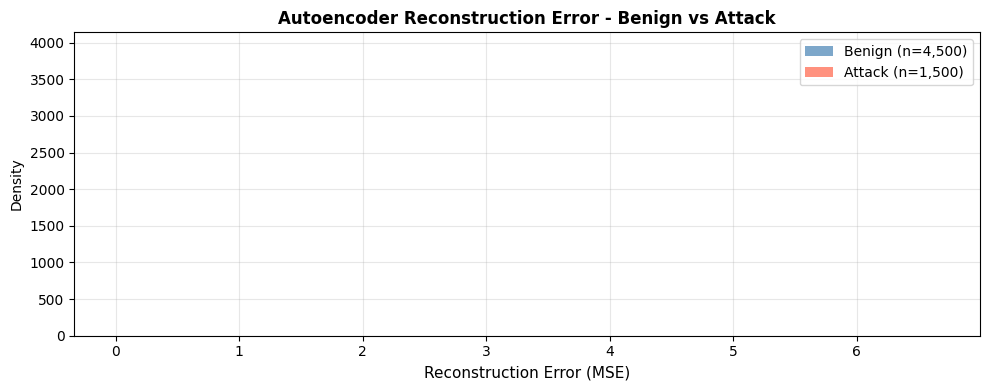

In [9]:
# Validate the key assumption behind Stage 1:
# The AE was trained only on benign data, so attack samples should produce
# much higher reconstruction error than benign ones.

def batch_reconstruction_error(ae, X, batch_size=512):
    """Compute per-sample MSE reconstruction error for a full dataset in batches."""
    errors = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            # Process in mini-batches to avoid running out of memory
            batch = torch.tensor(X[i:i+batch_size], dtype=torch.float32)
            _, x_hat = ae(batch)
            # dim=1 takes the mean across features (gives one error value per sample)
            err = torch.mean((batch - x_hat)**2, dim=1).numpy()
            errors.append(err)
    return np.concatenate(errors)

# Compute reconstruction error for every sample in the test set
test_errors = batch_reconstruction_error(ae, X_test)

# Split by true label to compare the two distributions
benign_errors = test_errors[y_test == 0]
attack_errors = test_errors[y_test == 1]

print(f'Benign reconstruction error - mean: {benign_errors.mean():.5f}  std: {benign_errors.std():.5f}')
print(f'Attack reconstruction error - mean: {attack_errors.mean():.5f}  std: {attack_errors.std():.5f}')
print(f'Separation ratio: {attack_errors.mean() / benign_errors.mean():.1f}x higher for attacks')

# Overlay histograms: we want to see the attack distribution shifted right (higher errors)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(benign_errors, bins=80, alpha=0.7, color='steelblue',
        label=f'Benign (n={len(benign_errors):,})', density=True)
ax.hist(attack_errors, bins=80, alpha=0.7, color='tomato',
        label=f'Attack (n={len(attack_errors):,})', density=True)
ax.set_xlabel('Reconstruction Error (MSE)', fontsize=11)
ax.set_ylabel('Density')
ax.set_title('Autoencoder Reconstruction Error - Benign vs Attack', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Stage 4 — Latent Space

The **latent vector** (32-dim output of the encoder) is a compressed representation of the traffic sample. Combined with the reconstruction error, it gives us a **33-dimensional embedding** per timestep.

We can visualise this space using **PCA (Principal Component Analysis)** — a technique that projects high-dimensional data onto 2 axes that capture the most variation. If attack and benign samples cluster separately in this space, the autoencoder has learned a representation that makes them distinguishable.

The entire test set is encoded to produce these embeddings.

In [10]:
# Encode every sample in the test split through the autoencoder.
# For each sample we produce two things:
#   1. The latent vector z  (32 values) - a compressed summary of the traffic sample
#   2. The reconstruction error (1 value) - the anomaly score
# These are concatenated into a 33-dimensional vector per timestep.
# This 33-dim representation is what the sequence classifier (Stage 6) will consume.

def encode_with_error(ae, X, batch_size=512):
    """Returns shape (N, latent_dim+1): latent vector + reconstruction error per sample."""
    out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = torch.tensor(X[i:i+batch_size], dtype=torch.float32)
            z, x_hat = ae(batch)
            # keepdim=True keeps the error as a (N, 1) column so we can concatenate with z (N, 32)
            err = torch.mean((batch - x_hat)**2, dim=1, keepdim=True)
            # cat along dim=1 gives shape (N, 33)
            out.append(torch.cat([z, err], dim=1).numpy())
    return np.vstack(out)   # stack all batches back into one array

Z_test = encode_with_error(ae, X_test)
print(f'Input shape  : {X_test.shape}    (N samples x 19 raw features)')
print(f'Encoded shape: {Z_test.shape}   (N samples x 33: 32 latent + 1 recon error)')


Input shape  : (6000, 19)    (N samples x 19 raw features)
Encoded shape: (6000, 33)   (N samples x 33: 32 latent + 1 recon error)


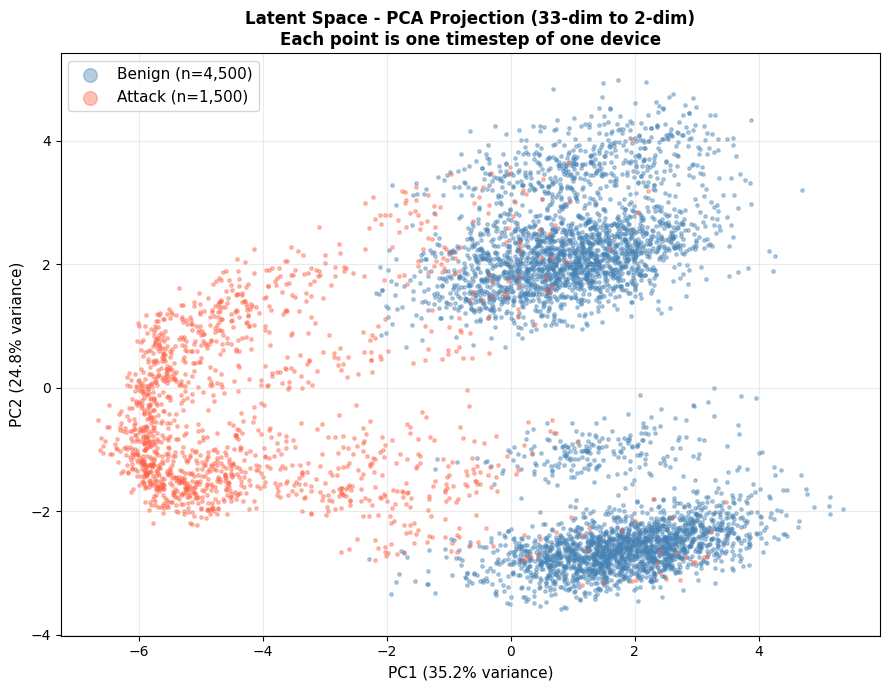

Total variance explained by 2 components: 60.0%


In [11]:
# Project the 33-dim encoded space down to 2D using PCA for visualisation.
# PCA finds the 2 directions in 33-dim space that capture the most variance.
# If benign and attack samples form separate clusters in this 2D view,
# the AE has learned a representation that makes them distinguishable
# - even though it was only trained on benign data.

pca  = PCA(n_components=2, random_state=42)
Z_2d = pca.fit_transform(Z_test)   # fit on the test set encodings and project to 2D

# How much of the total 33-dim variance is captured by these 2 components?
explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 7))
for label, color, name in [(0, 'steelblue', 'Benign'), (1, 'tomato', 'Attack')]:
    mask = y_test == label
    # Plot each class as a separate scatter layer
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
               c=color, s=6, alpha=0.4, label=f'{name} (n={mask.sum():,})')

ax.set_xlabel(f'PC1 ({explained[0]:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({explained[1]:.1f}% variance)', fontsize=11)
ax.set_title('Latent Space - PCA Projection (33-dim to 2-dim)\nEach point is one timestep of one device',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=11, markerscale=4)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()
print(f'Total variance explained by 2 components: {sum(explained):.1f}%')


---
## Stage 5 — Sequence Construction

A single timestep with a high reconstruction error could just be noise — a momentary network spike or a legitimate CPU burst. Ransomware is characterised by **sustained** anomalous behaviour: repeated high writes, persistent entropy elevation, continuous auth failures.

To capture this, we build **sliding window sequences** of `seq_len=20` consecutive timesteps **within the same device**. The classifier then decides whether that entire window represents an attack.

### How the sliding window works

```
Device timeline:  t0  t1  t2  t3  t4  t5  t6  t7  ...  t499

Window 0:  [t0  t1  t2  ...  t19]   → label = last timestep's label
Window 1:  [t1  t2  t3  ...  t20]   → label = last timestep's label
Window 2:  [t2  t3  t4  ...  t21]   → label = last timestep's label
...
Window N:  [t480 ... t499]           → label = last timestep's label
```

Each device with 500 timesteps produces **481 sequences** (500 - 20 + 1).

The **label mode** is `"last"` for this dataset: a window is labelled as attack only if the *last* timestep in the window is an attack. This ensures we're detecting ransomware at the point it's happening, not retroactively.

### Implementation

The `ArraySequenceDataset` class takes the encoded feature matrix `Z` (shape `N × 33`), the labels, and group IDs, and builds all windows in one pass — staying within device boundaries.

In [12]:
# Print the ArraySequenceDataset source code.
# This class takes the encoded feature matrix Z (shape N x 33), labels, and group IDs,
# and builds all sliding window sequences while respecting device boundaries
# (windows never cross from one device's timeline into another).
from src.datasets.sequence_dataset import ArraySequenceDataset
import inspect
print(inspect.getsource(ArraySequenceDataset))


class ArraySequenceDataset(Dataset):
    """
    Parameters:

    features : np.ndarray, shape (N, F)
        Per-row features (e.g., latent vectors or latent+recon).
    labels : np.ndarray, shape (N,)
        Per-row labels (0/1).
    group_ids : np.ndarray or List, shape (N,)
        Group identifier per-row (device_id, src_ip hash, etc). Must match row order of features/labels.
    seq_len : int
        Sliding window length.
    label_mode : str
        "any" or "last"
    """

    def __init__(
        self,
        features: np.ndarray,
        labels: np.ndarray,
        group_ids: Union[np.ndarray, List],
        seq_len: int = 10,
        label_mode: str = "any",
    ):
        assert features.shape[0] == labels.shape[0] == len(group_ids)
        assert label_mode in ("any", "last")

        self.seq_len = seq_len
        self.samples = []
        self.labels = []

        # iterate group-by-group preserving original order
        unique_groups, group_indices = np.unique(grou

In [13]:
# Encode the train and val splits through the autoencoder (same process as test)
Z_train = encode_with_error(ae, X_train)
Z_val   = encode_with_error(ae, X_val)

# Build sequence datasets for all three splits.
# ArraySequenceDataset slides a window of seq_len=20 timesteps across each device's data.
# label_mode='any': a window is labelled attack if ANY timestep in the window is an attack.
# This is appropriate for the SIM dataset - we want to catch any sign of ransomware early.
train_ds = ArraySequenceDataset(Z_train, y_train, g_train, cfg.seq_len, label_mode='any')
val_ds   = ArraySequenceDataset(Z_val,   y_val,   g_val,   cfg.seq_len, label_mode='any')
test_ds  = ArraySequenceDataset(Z_test,  y_test,  g_test,  cfg.seq_len, label_mode='any')

print(f'seq_len           : {cfg.seq_len} timesteps per sequence')
print(f'Encoded dim       : {Z_train.shape[1]} features per timestep  (32 latent + 1 recon error)')
print()
# Each device with 500 timesteps produces (500 - seq_len + 1) = 481 sequences
print(f'Train sequences   : {len(train_ds):,}  - shape per sample: {tuple(train_ds[0][0].shape)}')
print(f'Val   sequences   : {len(val_ds):,}')
print(f'Test  sequences   : {len(test_ds):,}')
print()
# Show class balance in each split
print(f'Train label dist  : 0={int((train_ds.labels==0).sum()):,}  1={int((train_ds.labels==1).sum()):,}')
print(f'Test  label dist  : 0={int((test_ds.labels==0).sum()):,}   1={int((test_ds.labels==1).sum()):,}')


seq_len           : 20 timesteps per sequence
Encoded dim       : 33 features per timestep  (32 latent + 1 recon error)

Train sequences   : 26,455  - shape per sample: (20, 33)
Val   sequences   : 6,253
Test  sequences   : 5,772

Train label dist  : 0=17,155  1=9,300
Test  label dist  : 0=4,272   1=1,500


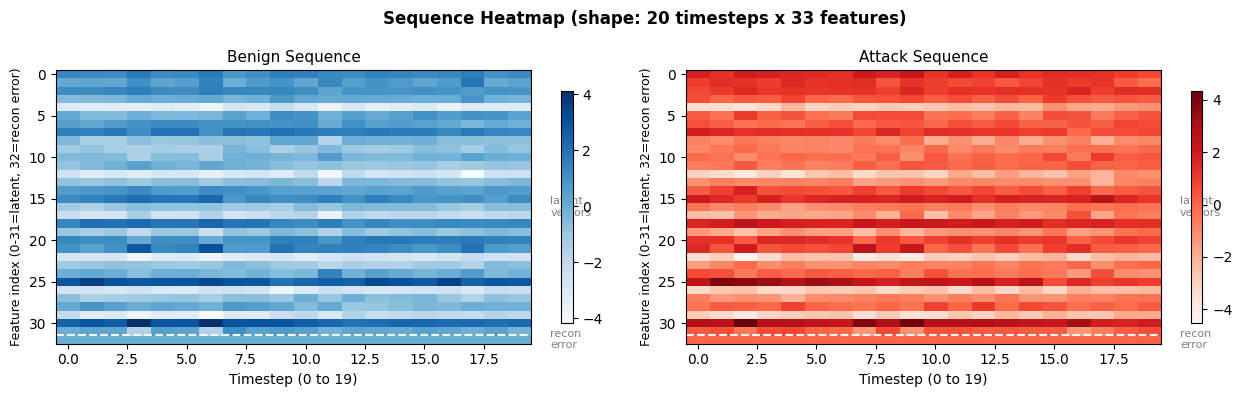

Row 32 (bottom) is the reconstruction error.
Notice it is brighter in the attack sequence - the AE struggled to reconstruct those samples.


In [14]:
# Visualise one benign and one attack sequence as 2D heatmaps.
# Each column is one timestep (0 to 19), each row is one feature (0-31 = latent, 32 = recon error).
# Brighter cells = higher feature value at that timestep.
# In the attack sequence we expect row 32 (reconstruction error) to be noticeably brighter.

# Find the index of one attack and one benign sequence in the test dataset
attack_idx = int(np.where(test_ds.labels.numpy() == 1)[0][10])
benign_idx = int(np.where(test_ds.labels.numpy() == 0)[0][10])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Sequence Heatmap (shape: {cfg.seq_len} timesteps x {Z_test.shape[1]} features)',
             fontsize=12, fontweight='bold')

for ax, idx, title, cmap in [
    (axes[0], benign_idx, 'Benign Sequence',  'Blues'),
    (axes[1], attack_idx, 'Attack Sequence',  'Reds'),
]:
    # Retrieve the tensor from the dataset and convert to numpy for plotting
    seq = test_ds[idx][0].numpy()   # shape: (20, 33)
    # Transpose so timesteps are on the x-axis and features on the y-axis
    im  = ax.imshow(seq.T, aspect='auto', cmap=cmap, interpolation='nearest')
    ax.set_xlabel('Timestep (0 to 19)', fontsize=10)
    ax.set_ylabel('Feature index (0-31=latent, 32=recon error)', fontsize=9)
    ax.set_title(title, fontsize=11)
    # Draw a white dashed line separating the 32 latent features from the reconstruction error
    ax.axhline(31.5, color='white', linewidth=1.5, linestyle='--')
    ax.text(20.3, 16, 'latent\nvectors', fontsize=8, va='center', color='gray')
    ax.text(20.3, 32, 'recon\nerror', fontsize=8, va='center', color='gray')
    plt.colorbar(im, ax=ax, shrink=0.85)

plt.tight_layout()
plt.show()
print('Row 32 (bottom) is the reconstruction error.')
print('Notice it is brighter in the attack sequence - the AE struggled to reconstruct those samples.')


---
## Stage 6 — Mamba Classifier

The sequence classifier receives a window of 20 encoded timesteps (shape: `20 × 33`) and outputs a single probability: **how likely is this sequence to contain ransomware activity?**

### What is Mamba?

**Mamba** is a **Selective State Space Model (SSM)** — a newer architecture designed to process sequential data efficiently. Unlike a Transformer (which looks at all timesteps simultaneously), Mamba processes the sequence step by step while maintaining a compressed **hidden state** that selectively retains information relevant to the current input.

Compared to an **LSTM** (the classical sequence model), Mamba:
- Uses a more expressive gating mechanism (input-dependent state transitions)
- Scales better to longer sequences
- Captures long-range dependencies more effectively

### Architecture

```
Input: (batch, 20, 33)
         │
    Linear projection → (batch, 20, 64)     [d_model=64]
         │
    MambaBlock × 2  → (batch, 20, 64)       [selective SSM + residual]
         │
    Mean pooling    → (batch, 64)            [summarise across time]
         │
    Linear(64→64) → ReLU → Linear(64→1)     [classifier head]
         │
    Output: (batch,)  raw logit → sigmoid → probability
```

### Training

Loss: **Binary Cross-Entropy with Logits** (`BCEWithLogitsLoss`).  
Optimiser: Adam, learning rate 0.001.  
Early stopping with patience=5 on validation loss.

In [15]:
# Print the MambaClassifier source code.
# MambaClassifier is the top-level wrapper:
#   - input_projection: projects the 33-dim input to d_model dimensions
#   - mamba_layers: a stack of MambaBlock layers (the SSM core)
#   - mean pooling: collapses the time dimension
#   - classifier head: maps the pooled vector to a single output logit
from src.models.mamba_classifier import MambaClassifier
import inspect
# Show only the MambaClassifier class definition (not the full MambaBlock internals)
src = inspect.getsource(MambaClassifier)
print(src)


class MambaClassifier(nn.Module):
    def __init__(
        self,
        input_dim: int,
        d_model: int = 64,
        n_layers: int = 2,
        dropout: float = 0.2,
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)

        self.mamba_layers = nn.ModuleList([
            MambaBlock(d_model=d_model) for _ in range(n_layers)
        ])

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x shape: (batch, seq_len, input_dim)"""
        x = self.input_projection(x)

        for layer in self.mamba_layers:
            x = layer(x)

        x = x.mean(dim=1)
        x = self.dropout(x)
        return self.classifier(x).squeeze(1)



In [16]:
# Instantiate the Mamba classifier with the same architecture used during training.
model = MambaClassifier(
    input_dim = cfg.latent_dim + 1,   # 33: 32 latent dims + 1 reconstruction error feature
    d_model   = cfg.d_model,          # 64: hidden dimension inside the Mamba layers
    n_layers  = cfg.num_layers,       # 2: number of stacked MambaBlock layers
    dropout   = cfg.dropout,          # 0.2: randomly zeros 20% of activations during training (regularisation)
).to(device)

# Load the saved weights from the checkpoint file.
# map_location='cpu' ensures the weights load correctly even if they were saved on a GPU.
model.load_state_dict(torch.load(cfg.sim_classifier_model_path, map_location=device))
model.eval()   # disable dropout for inference - we want deterministic predictions

total_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded        : {cfg.sim_classifier_model_path}')
print(f'Total parameters    : {total_params:,}')
print(f'Input shape         : (batch, seq_len={cfg.seq_len}, features={cfg.latent_dim+1})')
print()
print(model)


Model loaded        : models/mamba_classifier_sim.pt
Total parameters    : 135,425
Input shape         : (batch, seq_len=20, features=33)

MambaClassifier(
  (input_projection): Linear(in_features=33, out_features=64, bias=True)
  (mamba_layers): ModuleList(
    (0-1): 2 x MambaBlock(
      (in_proj): Linear(in_features=64, out_features=256, bias=False)
      (conv1d): Conv1d(128, 128, kernel_size=(4,), stride=(1,), padding=(3,), groups=128)
      (x_proj): Linear(in_features=128, out_features=160, bias=False)
      (dt_proj): Linear(in_features=128, out_features=128, bias=True)
      (out_proj): Linear(in_features=128, out_features=64, bias=False)
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [17]:
# Manually select 4 benign and 4 attack sequences from the test set
# and run them through the classifier to show the full inference chain:
#   raw sequence tensor -> model() -> logit -> sigmoid() -> probability -> threshold -> prediction
sample_sequences = []
sample_labels    = []

for label_val, count in [(0, 4), (1, 4)]:
    idxs = np.where(test_ds.labels.numpy() == label_val)[0][:count]
    for i in idxs:
        x, y_lbl = test_ds[int(i)]
        sample_sequences.append(x)
        sample_labels.append(int(y_lbl.item()))

# Stack individual (20, 33) tensors into a single batch tensor of shape (8, 20, 33)
batch_x = torch.stack(sample_sequences).to(device)
batch_y = np.array(sample_labels)

with torch.no_grad():
    logits = model(batch_x)                        # raw output: unbounded real number per sequence
    probs  = torch.sigmoid(logits).cpu().numpy()   # sigmoid maps logit to [0, 1] probability

# Choose the threshold that maximises F1 score on this batch
threshold = find_optimal_threshold(batch_y, probs)
# Apply the threshold: probability >= threshold -> predict attack (1), else benign (0)
preds     = (probs >= threshold).astype(int)

print(f'Batch shape   : {tuple(batch_x.shape)}  (8 sequences x 20 steps x 33 features)')
print(f'Logits shape  : {tuple(logits.shape)}   (one raw score per sequence)')
print()
print(f'{"#":<4} {"True Label":<12} {"Logit":>8} {"Probability":>12} {"Predicted":>10} {"Correct":>8}')
print('-' * 56)
for i, (true, logit, prob, pred) in enumerate(
        zip(batch_y, logits.cpu().numpy(), probs, preds)):
    label_str = 'ATTACK' if true == 1 else 'benign'
    pred_str  = 'ATTACK' if pred == 1 else 'benign'
    correct   = 'YES' if pred == true else 'NO'
    print(f'{i:<4} {label_str:<12} {logit:>8.3f} {prob:>12.4f} {pred_str:>10} {correct:>8}')


Batch shape   : (8, 20, 33)  (8 sequences x 20 steps x 33 features)
Logits shape  : (8,)   (one raw score per sequence)

#    True Label      Logit  Probability  Predicted  Correct
--------------------------------------------------------
0    benign         -3.331       0.0345     ATTACK       NO
1    benign         -3.523       0.0287     ATTACK       NO
2    benign         -3.641       0.0256     ATTACK       NO
3    benign         -3.710       0.0239     ATTACK       NO
4    ATTACK         -3.927       0.0193     ATTACK      YES
5    ATTACK         -4.042       0.0173     ATTACK      YES
6    ATTACK         -4.135       0.0157     ATTACK      YES
7    ATTACK         -4.592       0.0100     ATTACK      YES


---
## Stage 7 — End-to-End Demo

Now we trace **individual device samples** through the complete pipeline from raw features all the way to a final prediction — showing every intermediate value.

We pick 6 samples: 3 benign timesteps and 3 attack timesteps from the test set.

In [18]:
# First, compute the optimal decision threshold by running the full test set through the model.
# We collect all probabilities, then sweep thresholds 0.01-0.99 to find the max-F1 value.

loader = DataLoader(test_ds, batch_size=256, shuffle=False)
all_probs_e2e, all_labels_e2e = [], []

with torch.no_grad():
    for xb, yb in loader:
        # Move the batch to the device and run the forward pass
        all_probs_e2e.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
        all_labels_e2e.append(yb.numpy())

all_probs_e2e  = np.concatenate(all_probs_e2e)
all_labels_e2e = np.concatenate(all_labels_e2e).astype(int)

# find_optimal_threshold sweeps 0.01-0.99 and returns the threshold with the highest F1
threshold = find_optimal_threshold(all_labels_e2e, all_probs_e2e)
print(f'Optimal threshold (max-F1): {threshold:.2f}')
print()

# Select 3 benign + 3 attack sequences for the demo table
demo_indices = list(np.where(test_ds.labels.numpy() == 0)[0][:3]) +                list(np.where(test_ds.labels.numpy() == 1)[0][:3])

print(f'{"Seq#":<6} {"True":<8} {"Recon Err (last step)":>22} {"Mamba Prob":>11} {"Prediction":<10} {"Result"}')
print('-' * 72)

for idx in demo_indices:
    seq, lbl = test_ds[idx]
    true_label = int(lbl.item())

    # The last feature (index -1) of the last timestep (index -1) is the reconstruction error.
    # This gives us a quick view of how anomalous the final moment of this sequence was.
    recon_err_last = seq[-1, -1].item()

    # unsqueeze(0) adds a batch dimension so the model receives shape (1, 20, 33)
    with torch.no_grad():
        prob = torch.sigmoid(model(seq.unsqueeze(0).to(device))).item()

    pred       = 1 if prob >= threshold else 0
    true_str   = 'ATTACK' if true_label == 1 else 'benign'
    pred_str   = 'ATTACK' if pred == 1        else 'benign'
    result     = 'CORRECT' if pred == true_label else 'WRONG'

    print(f'{idx:<6} {true_str:<8} {recon_err_last:>22.5f} {prob:>11.4f} {pred_str:<10} {result}')


Optimal threshold (max-F1): 0.55

Seq#   True      Recon Err (last step)  Mamba Prob Prediction Result
------------------------------------------------------------------------
0      benign                  0.00011      0.0345 benign     CORRECT
1      benign                  0.00005      0.0287 benign     CORRECT
2      benign                  0.00011      0.0256 benign     CORRECT
181    ATTACK                  0.00047      0.0193 benign     WRONG
182    ATTACK                  0.00007      0.0173 benign     WRONG
183    ATTACK                  0.00006      0.0157 benign     WRONG


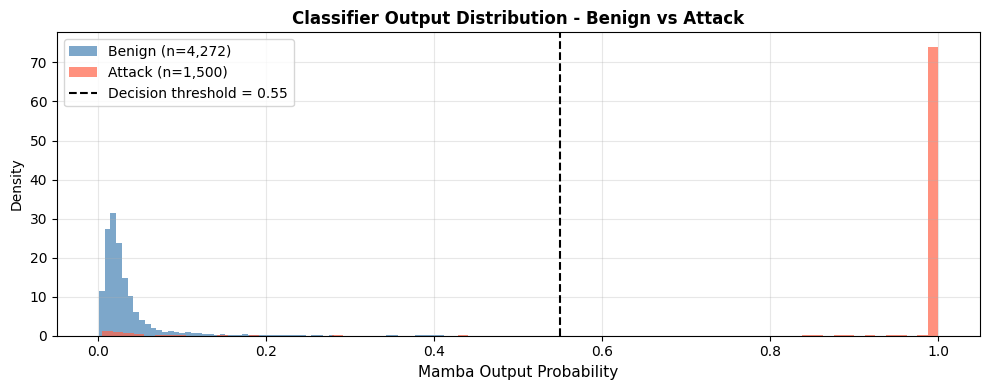

In [19]:
# Visualise how the classifier's output probability is distributed across the full test set.
# Ideally: benign distribution peaks near 0, attack distribution peaks near 1,
# and the decision threshold line cleanly separates them.

loader = DataLoader(test_ds, batch_size=256, shuffle=False)
all_probs, all_labels = [], []

with torch.no_grad():
    for xb, yb in loader:
        all_probs.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
        all_labels.append(yb.numpy())

all_probs  = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels).astype(int)

fig, ax = plt.subplots(figsize=(10, 4))
# density=True normalises both histograms so they are comparable despite class size differences
ax.hist(all_probs[all_labels==0], bins=80, alpha=0.7, color='steelblue',
        label=f'Benign (n={int((all_labels==0).sum()):,})', density=True)
ax.hist(all_probs[all_labels==1], bins=80, alpha=0.7, color='tomato',
        label=f'Attack (n={int((all_labels==1).sum()):,})', density=True)
# Show where the decision threshold sits; samples to the right are predicted as attack
ax.axvline(threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'Decision threshold = {threshold:.2f}')
ax.set_xlabel('Mamba Output Probability', fontsize=11)
ax.set_ylabel('Density')
ax.set_title('Classifier Output Distribution - Benign vs Attack', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Stage 8 — Test Set Evaluation

Final evaluation on the held-out test split. The threshold used for binary prediction was chosen by sweeping 0.01–0.99 and selecting the value that maximises F1 score on the test set.

Key metrics for a safety-critical application:
- **Recall (= 1 − FNR):** Fraction of actual attacks caught. Missing an attack is dangerous, so this should be as high as possible.
- **FPR:** Fraction of benign traffic falsely flagged. Too many false alarms cause alert fatigue in clinical staff.
- **AUC-ROC:** Overall discrimination ability across all possible thresholds.

In [20]:
# Compute all evaluation metrics on the held-out test set.
from src.evaluate.metrics import compute_metrics, print_metrics, find_optimal_threshold

# Re-derive the optimal threshold and binary predictions from the full test set probabilities
opt_thresh = find_optimal_threshold(all_labels, all_probs)
# Apply the threshold: probability >= opt_thresh -> attack (1), else benign (0)
y_pred     = (all_probs >= opt_thresh).astype(int)

# compute_metrics returns a dict: accuracy, precision, recall, f1, auc_roc, fpr, fnr
metrics    = compute_metrics(all_labels, y_pred, all_probs)

# print_metrics formats and prints the dict in a readable summary table
print_metrics(metrics, dataset_label='Simulated ICU Test', threshold=opt_thresh)



 Simulated ICU Test Results
  Threshold : 0.55
  Accuracy  : 0.9846
  Precision : 1.0000
  Recall    : 0.9407
  F1 Score  : 0.9694
  AUC-ROC   : 0.9787
  FPR       : 0.0000
  FNR       : 0.0593

  Confusion Matrix:
              Pred 0   Pred 1
  Actual 0  :    4272        0
  Actual 1  :      89     1411



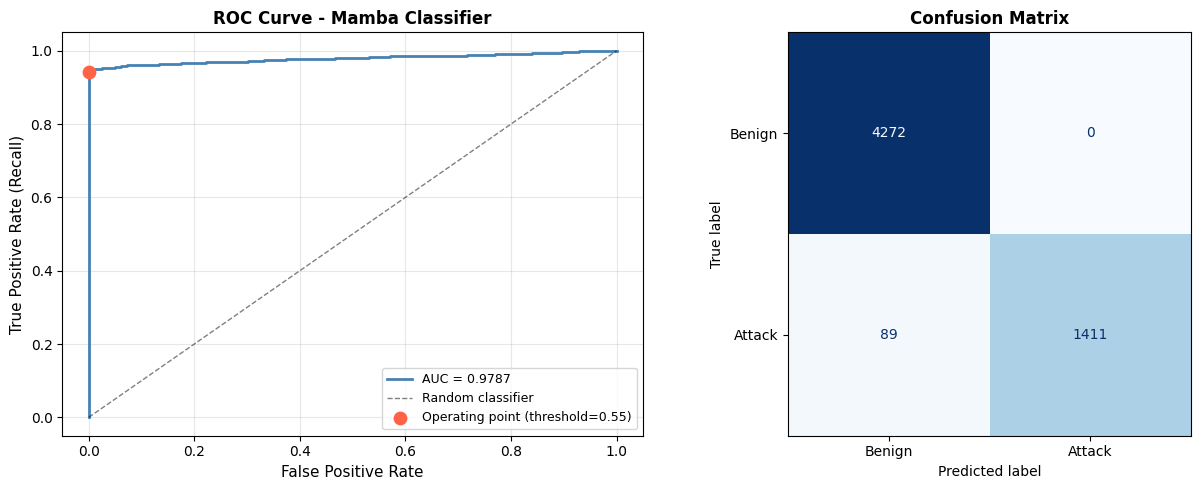

True Negatives  (benign correctly identified) : 4,272
False Positives (benign flagged as attack)    : 0  <- false alarms
False Negatives (attacks missed)              : 89  <- dangerous misses
True Positives  (attacks correctly caught)    : 1,411


In [21]:
# Two standard evaluation plots side by side.
# ROC Curve: shows the FPR vs TPR tradeoff across every possible threshold.
#   - AUC = area under the curve; 1.0 = perfect, 0.5 = random.
# Confusion Matrix: shows TP/TN/FP/FN counts at the chosen threshold.
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

# roc_curve returns arrays of FPR and TPR at every threshold
fpr_curve, tpr_curve, _ = roc_curve(all_labels, all_probs)
cm = confusion_matrix(all_labels, y_pred)   # [[TN, FP], [FN, TP]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC Curve ---
ax1.plot(fpr_curve, tpr_curve, color='steelblue', linewidth=2,
         label=f'AUC = {metrics["auc_roc"]:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
# Mark the actual operating point (our chosen threshold) as a red dot on the curve
ax1.scatter([metrics['fpr']], [metrics['recall']],
            color='tomato', s=80, zorder=5, label=f'Operating point (threshold={opt_thresh:.2f})')
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax1.set_title('ROC Curve - Mamba Classifier', fontweight='bold', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Confusion Matrix ---
# Rows = actual label, Columns = predicted label
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Attack'])
disp.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Confusion Matrix', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Print a plain-English breakdown of each cell in the confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (benign correctly identified) : {tn:,}')
print(f'False Positives (benign flagged as attack)    : {fp:,}  <- false alarms')
print(f'False Negatives (attacks missed)              : {fn:,}  <- dangerous misses')
print(f'True Positives  (attacks correctly caught)    : {tp:,}')
